# Tutorial — Construtor de Modelos (`ModelSegmenterUI`)

`ModelSegmenter` é o segmentador **orientado a modelo** do `yggdrasil.credit_risk`. Diferente dos
segmentadores `lgd`/`pd` (que crescem uma árvore de bins direto nas features), aqui o fluxo é:
**analisar variáveis → selecionar → treinar um modelo (logística / ML) → segmentar o *score* do modelo
em ratings → validar e exportar**. Um mesmo objeto atende **classificação** (ex.: PD) e **regressão**
(ex.: LGD) via `task_type`.

Este tutorial é focado na **UI** (`ModelSegmenterUI`): um *workbench* de 5 abas em `ipywidgets`. Como um
notebook estático não registra cliques, cada aba é explicada e em seguida **reproduzida em código** pelo
segmentador interno `ui.seg` (e/ou pelos *handlers* `ui._on_*`, que são exatamente o que os botões chamam).

> **Contrato de dados:** um `pandas.DataFrame` com a coluna-alvo (`target`), features numéricas e/ou
> categóricas, e — opcionais — coluna de amostra (`amostra`: DES/OOT…) e coluna de data (`dt_ref`).
> Requer os extras `[ui]` (ipywidgets) para a interface; o núcleo roda sem ela.

## 0. Setup e dataset sintético

Geramos uma base de **classificação** (alvo binário) com 6 features numéricas, 1 categórica, coluna de
safra (`dt_ref`) e amostra `DES`/`OOT` — o mesmo formato usado nos testes do módulo.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from IPython.display import display   # autossuficiente fora do kernel (nbconvert etc.)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

n = 3000
X, y = make_classification(n_samples=n, n_features=6, n_informative=4,
                           weights=[0.75], random_state=0)
df = pd.DataFrame(X, columns=[f"feat_{i:02d}" for i in range(6)])
df["target"] = y                                            # alvo binário 0/1
df["feat_cat"] = rng.choice(["A", "B", "C", "D"], size=n, p=[.4, .3, .2, .1])  # categórica
df["dt_ref"] = rng.choice(pd.date_range("2023-01-01", periods=10, freq="MS"), size=n)
df["amostra"] = np.where(df["dt_ref"] >= pd.Timestamp("2023-08-01"), "OOT", "DES")
df.head()

,feat_00,feat_01,feat_02,feat_03,feat_04,feat_05,target,feat_cat,dt_ref,amostra
0,-1.1007,2.5760,1.9988,-0.5546,0.2658,-3.2138,0,B,2023-09-01,OOT
1,-0.2551,2.1487,1.2914,-1.3765,-2.3123,0.1101,0,A,2023-02-01,DES
2,1.7509,-1.5617,0.2844,-0.8613,-0.9995,4.0925,0,A,2023-06-01,DES
3,1.0922,2.8787,1.5693,-0.8472,-3.9025,1.5311,0,A,2023-08-01,OOT
4,0.0800,-0.4519,-0.2358,-0.4253,-0.4047,0.9589,0,C,2023-10-01,OOT


## 1. Abrindo a UI (`ModelSegmenterUI`)

Instancie a UI com o mesmo contrato e exiba o objeto — o Jupyter chama `_ipython_display_()` e mostra o
*workbench* com 5 abas:

| Aba | Para quê |
|-----|----------|
| **① Variáveis** | ranking por IV, seleção (auto/manual) e categorização das candidatas |
| **② Análise de variáveis** | diagnóstico por variável: log-odds, distribuição, PSI, inversão |
| **③ Modelo** | escolher algoritmo (logística / RF / GBM), treinar, ver métricas e SHAP |
| **④ Ratings & Score** | segmentar o *score* em ratings e checar bad-rate / monotonia |
| **⑤ Validar & Exportar** | backtest, PSI, exportar, salvar/carregar e logar no MLflow |

`ui.seg` é o `ModelSegmenter` por trás da interface — usaremos ele para reproduzir cada aba em código.

In [2]:
from yggdrasil.credit_risk.model import ModelSegmenterUI

ui = ModelSegmenterUI(
    df, target="target", task_type="classification",
    sample_col="amostra", ref_sample="DES", date_col="dt_ref",
)
ui   # exibe o workbench (ipywidgets). Alternativas: ui.display() ou display(ui.panel)

In [3]:
seg = ui.seg   # o ModelSegmenter por trás da UI — todos os métodos abaixo saem daqui
type(seg).__name__, seg.task_type

('ModelSegmenter', 'classification')

## 2. Aba ① Variáveis — ranking e seleção

Na UI: o ranking por **IV** aparece na tabela; os sliders **IV mínimo** / **PSI máximo** + o botão
**Auto-selecionar** incluem/excluem candidatas; também dá para incluir/excluir manualmente e marcar a
*categoria* de cada variável (`manter`/`revisar`/`descartar`).

Em código, isso é `seg.variable_iv()` (ranking) e `seg.auto_select(...)` (seleção automática).

In [4]:
seg.variable_iv()   # ranking: variavel, tipo, n_bins, iv, forca, tendencia, n_inversoes, psi_*, incluida, ...

,variavel,tipo,n_bins,iv,forca,tendencia,n_inversoes,psi_OOT,pior_psi,estabilidade,incluida,categoria,bins_manuais
0,feat_03,num,5,1.1455,suspeito,crescente,0,0.0109,0.0109,estável,True,None,False
1,feat_04,num,5,0.6955,suspeito,crescente,0,0.0036,0.0036,estável,True,None,False
2,feat_05,num,5,0.6009,suspeito,decrescente,0,0.0031,0.0031,estável,True,None,False
3,feat_02,num,5,0.2495,médio,decrescente,0,0.0043,0.0043,estável,True,None,False
4,feat_00,num,4,0.0538,fraco,decrescente,0,0.0022,0.0022,estável,True,None,False
5,feat_01,num,3,0.0535,fraco,decrescente,0,0.0031,0.0031,estável,True,None,False
6,feat_cat,cat,4,0.0003,inútil,crescente,0,0.0054,0.0054,estável,True,None,False


In [5]:
# Auto-seleção (botão "Auto-selecionar"). min_iv=0.0 não filtra por IV, mas a inclusão ainda
# respeita max_psi=0.25 (candidata com pior PSI > 0.25 sai); require_monotonic está desligado por padrão.
seg.auto_select(min_iv=0.0, max_psi=0.25)
seg.selected_features()   # features que entrarão no modelo

['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_05', 'feat_cat']

## 3. Aba ② Análise de variáveis — diagnóstico por variável

Na UI: escolhe-se a variável e a amostra e clica **Analisar variável**, gerando cartões de resumo + gráficos
(log-odds por bin, distribuição, série temporal, PSI por safra e inversão de risco entre amostras/safras).

Em código: `seg.variable_summary(feat)` e os `plot_variable_*`.

In [6]:
feat = seg.variable_iv().iloc[0]["variavel"]   # variável de maior IV
print("Variável analisada:", feat)
seg.variable_summary(feat)                          # %missing, stats, IV, força, tendência, PSI por amostra

Variável analisada: feat_03


{'variavel': 'feat_03',
 'tipo': 'num',
 'n': 2104,
 'n_missing': 0,
 'pct_missing': 0.0,
 'incluida': True,
 'categoria': 'manter',
 'media': -0.7271,
 'mediana': -0.8218,
 'desvio': 1.1914,
 'min': -4.3376,
 'p5': -2.5902,
 'p95': 1.4704,
 'max': 3.8928,
 'iv': 1.1455,
 'forca': 'suspeito',
 'tendencia': 'crescente',
 'n_inversoes': 0,
 'psi': {'OOT': 0.0109},
 'pior_psi': 0.0109}

In [7]:
seg.plot_variable_logodds(feat)   # barras (repr_%) + linha (log-odds/risco) por bin

<Figure size 1140x510 with 2 Axes>

In [8]:
seg.plot_variable_inversion_by_sample(feat)   # risco por bin em cada amostra — cruzamentos = inversão

<Figure size 1140x600 with 1 Axes>

## 4. Aba ③ Modelo — treino e métricas

Na UI: escolhe-se o **algoritmo** no dropdown e clica **Treinar modelo**. O dropdown lista só os
algoritmos válidos para o `task_type` atual — nesta UI de **classificação**: *Regressão Logística*
(`"logistica"`, padrão), *Random Forest* (`"random_forest"`) e *Gradient Boosting* (`"gradient_boosting"`);
o *Linear* (`"linear"`) só aparece com `task_type="regression"`. O treino calcula o `score_` de todas as
linhas e mostra as **métricas** por amostra + gráficos (ROC, KS, distribuição do score). O botão
**Calcular SHAP** gera o beeswarm e a barra de importância.

O *handler* do botão de treino é `ui._on_fit(None)`; em código direto é `seg.fit(...)`.

In [9]:
seg.fit("logistica")          # treina a regressão logística nas features selecionadas
seg.metrics()                  # por amostra: amostra, n, auc, gini, ks, accuracy, f1, ... (DES e OOT)

,amostra,n,auc,gini,ks,ks_cutoff,accuracy,f1,precision,recall,brier,logloss
0,DES,2104,0.7811,0.5621,0.4895,0.2980,0.7833,0.6076,0.5577,0.6673,0.1385,0.4555
1,OOT,896,0.7827,0.5654,0.4982,0.3085,0.7879,0.6245,0.5874,0.6667,0.1429,0.4655


In [10]:
seg.plot_roc()   # curva ROC (classificação)

<Figure size 810x750 with 1 Axes>

In [11]:
seg.plot_ks()    # curva KS (classificação)

<Figure size 960x630 with 1 Axes>

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


,feature,mean_abs_shap
0,num__feat_03,0.5827
1,num__feat_05,0.4898
2,num__feat_00,0.4560
3,num__feat_04,0.4234
4,num__feat_02,0.1139
5,num__feat_01,0.0697
6,cat__feat_cat_A,0.0530
7,cat__feat_cat_C,0.0505
8,cat__feat_cat_B,0.0495
9,cat__feat_cat_D,0.0066


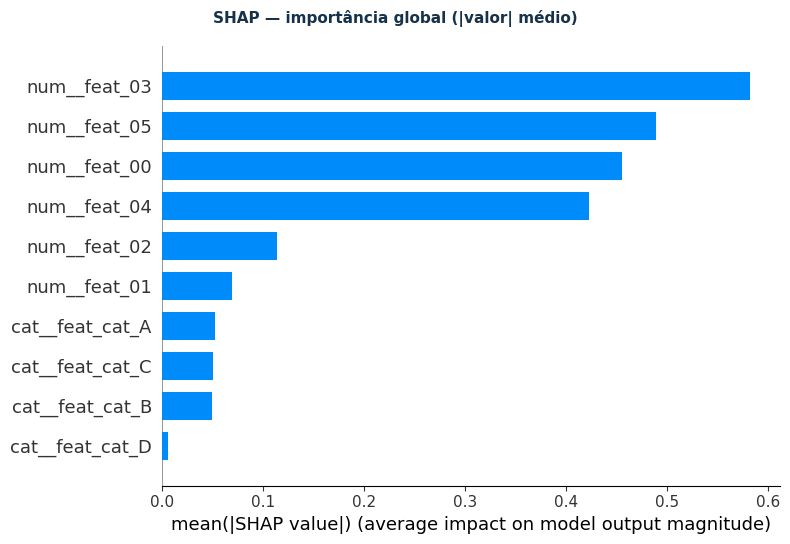

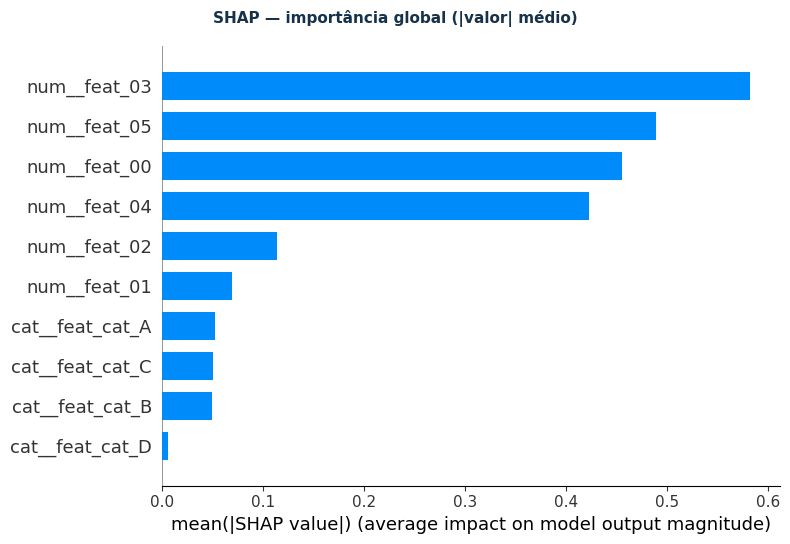

In [12]:
# SHAP. O botão "Calcular SHAP" gera o beeswarm + a barra (sample_size=800); shap_importance() é um
# extra disponível em código. Depende do pacote `shap` (já no core do yggdrasil, separado do extra [ui]).
display(seg.shap_importance().head(10))
seg.plot_shap_bar(max_display=10)

## 5. Aba ④ Ratings & Score — segmentando o *score*

Na UI: escolhe-se o **método** (`decis`, `quantil`, `arvore`, `optbin`), o nº de ratings e a **fusão
monotônica**, e clica **Gerar ratings**. O *score* do modelo é então segmentado em ratings, com tabela
(bad-rate por rating), distribuição e diagnóstico de inversão/monotonia.

Em código: `seg.build_ratings(...)` + `seg.rating_table()`.

In [13]:
seg.build_ratings(method="quantil", n_ratings=10, monotonic_fusion=True)
seg.rating_table()   # por rating (em ordem): n, repr_%, event_rate por amostra

,rating,n,repr_%,event_rate_DES,event_rate_OOT
0,A,211,10.0000,0.1327,0.1304
1,B,420,20.0000,0.1095,0.1311
2,C,211,10.0000,0.0853,0.0417
3,D,210,10.0000,0.1238,0.1139
4,E,210,10.0000,0.0952,0.1573
5,F,211,10.0000,0.1848,0.2051
6,G,210,10.0000,0.3333,0.3535
7,H,210,10.0000,0.5048,0.5568
8,I,211,10.0000,0.8341,0.8043


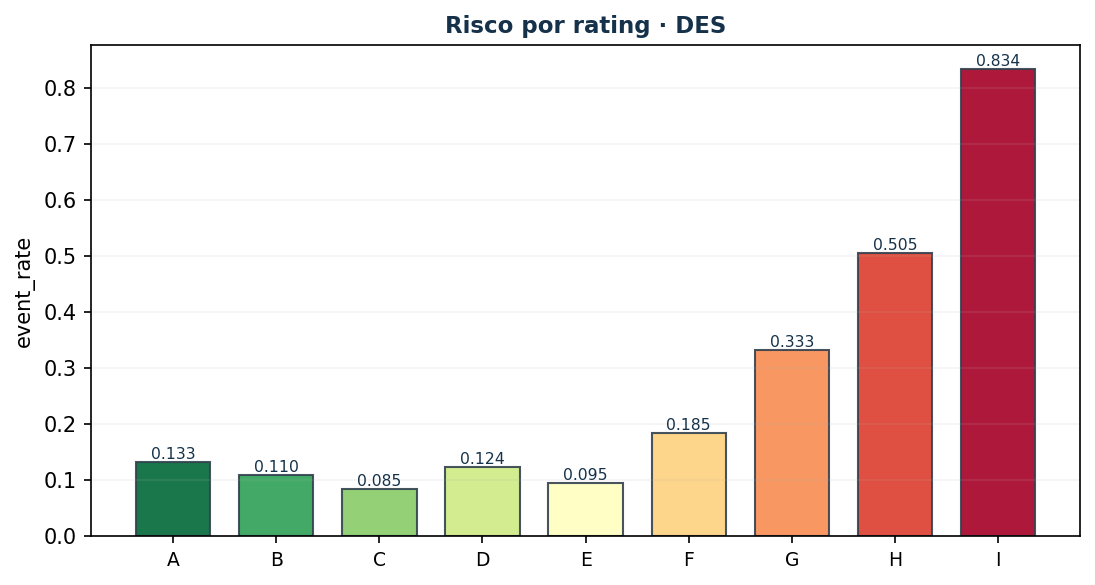

In [14]:
seg.plot_rating_badrate()        # risco (event rate) por rating

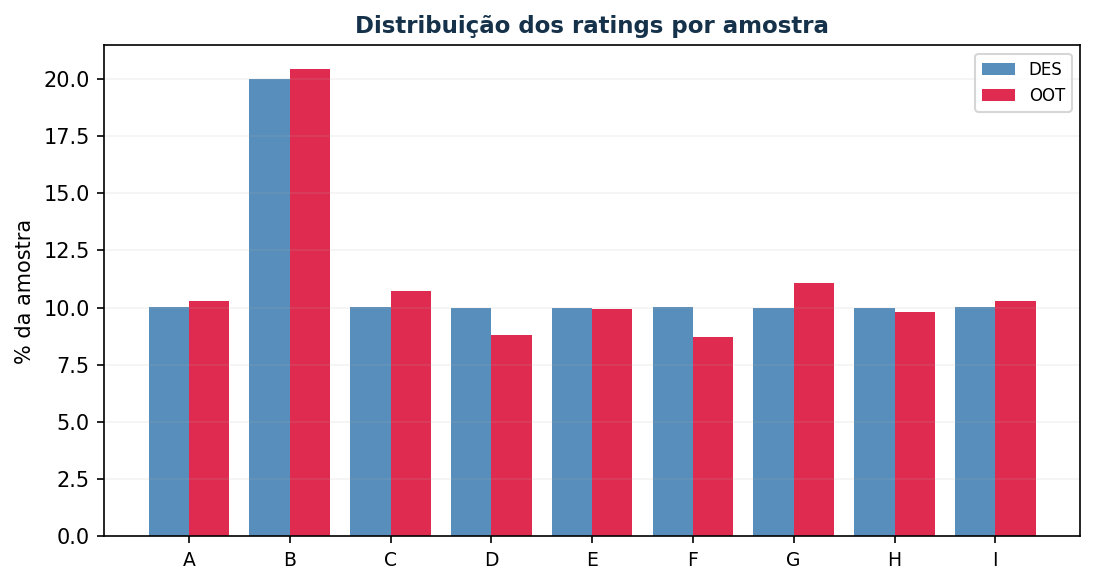

In [15]:
seg.plot_rating_distribution()   # distribuição (%) dos ratings por amostra

## 6. Aba ⑤ Validar & Exportar — backtest, PSI, export, persistência

Na UI: **Backtest** (previsto × realizado por safra), **PSI** da distribuição de ratings,
**Exportar DataFrame** (gera `ui.result` = base + colunas `score`/`rating`), **Salvar/Carregar**
(JSON + modelo `joblib`) e **Registrar no MLflow**.

In [16]:
display(seg.psi())                # PSI da distribuição de ratings por amostra (não-DES)
seg.backtest("dt_ref")            # por safra: n, previsto_medio, realizado_medio, gap, status

,amostra,psi,classificacao
0,OOT,0.0051,estável


,safra,n,previsto_medio,realizado_medio,gap,status
0,2023-01,323,0.2408,0.2539,-0.0130,ok
1,2023-02,303,0.2675,0.2475,0.0200,ok
2,2023-03,292,0.2440,0.2055,0.0385,ok
3,2023-04,285,0.2557,0.2491,0.0066,ok
4,2023-05,302,0.2319,0.2417,-0.0099,ok
5,2023-06,305,0.2625,0.2852,-0.0228,ok
6,2023-07,294,0.2586,0.2755,-0.0170,ok
7,2023-08,302,0.2391,0.2517,-0.0126,ok
8,2023-09,312,0.2582,0.2692,-0.0111,ok
9,2023-10,282,0.2564,0.2730,-0.0166,ok


In [17]:
# Exportar: base + score + rating. Na UI isto preenche ui.result.
scored = seg.assign(col_score="score", col_rating="rating")
scored[["target", "amostra", "score", "rating"]].head()

,target,amostra,score,rating
0,0,OOT,0.4837,H
1,0,DES,0.1146,C
2,0,DES,0.1462,C
3,0,OOT,0.1168,C
4,0,OOT,0.2392,F


In [18]:
# Persistência: grava o JSON de config + <path>.model.joblib (o modelo) AO LADO, no mesmo destino.
# No Databricks use um caminho persistente (DBFS/Volumes), ex.: seg.save("/dbfs/tmp/modelo_seg.json") —
# o cwd do driver é efêmero. O load() precisa do MESMO destino (JSON + .model.joblib) e do mesmo df.
seg.save("modelo_seg.json")
# Recarregar em outra sessão (load() devolve um NOVO segmentador):
# from yggdrasil.credit_risk.model import ModelSegmenter
# seg2 = ModelSegmenter(df, target="target", task_type="classification", sample_col="amostra",
#                       ref_sample="DES", date_col="dt_ref", verbose=False).load("modelo_seg.json", df)

# Escorar dados novos (aplica modelo + ratings):
seg.predict(df.head(5))[["score", "rating"]]

,score,rating
0,0.4837,H
1,0.1146,C
2,0.1462,C
3,0.1168,C
4,0.2392,F


In [19]:
# MLflow (descomente em ambiente com tracking, ex.: Databricks):
# run_id = seg.log_to_mlflow(experiment="/Shared/model_segmenter", run_name="modelo_v1")
# print("run_id:", run_id)

## 7. Dirigindo a UI por código (cliques programáticos)

Cada botão da UI chama um *handler* `ui._on_*`. Dá para reproduzir o fluxo inteiro sem clicar — útil para
testes/automação. Eles operam sobre o **mesmo** `ui.seg`, então o estado fica refletido na interface.

In [20]:
ui._on_fit(None)             # = clicar "Treinar"
ui._on_build_ratings(None)   # = clicar "Gerar ratings"
ui._on_export(None)          # = clicar "Exportar" -> preenche ui.result
ui.result.shape, ui.seg.score_ is not None

((3000, 12), True)

## 8. Notas

- **Classificação × regressão:** o mesmo `ModelSegmenter`/`ModelSegmenterUI` atende os dois via
  `task_type="classification"` (alvo 0/1; métricas AUC/Gini/KS) ou `"regression"` (alvo contínuo;
  métricas RMSE/MAE/R²; troque o algoritmo para `"linear"`/`"random_forest"`/`"gradient_boosting"`).
- **`ui.seg`** dá acesso direto a todos os métodos do segmentador; **`ui.result`** guarda a base exportada.
- **Sem interface:** o núcleo (`ModelSegmenter`) roda sem ipywidgets — use os métodos diretamente.
- Outros tutoriais (mesma pasta): `00_tutorial_yggdrasil`, `01_tutorial_lgd`, `02_tutorial_eda_features`,
  `03_tutorial_feature_selection`, `04_tutorial_lgd_segmenter`, `05_tutorial_pd_segmenter`,
  `07_tutorial_esteira_ml_mlflow`, `08_tutorial_validacao_lgd`.